In [ ]:
!pip install -q open-clip-torch tqdm

import sys
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive/liya_diploma'
    AI_TOOLKIT = '/content/ai-toolkit'
    sys.path.insert(0, DRIVE_ROOT)
    sys.path.insert(0, AI_TOOLKIT)
except ModuleNotFoundError:
    # Local run: find project root by looking for scripts/ directory
    _here = Path().resolve()
    DRIVE_ROOT = str(_here if (_here / 'scripts').exists() else _here.parent)
    AI_TOOLKIT = str(Path(DRIVE_ROOT).parent / 'ai-toolkit')
    sys.path.insert(0, DRIVE_ROOT)
    sys.path.insert(0, AI_TOOLKIT)

print(f"DRIVE_ROOT: {DRIVE_ROOT}")

DRIVE_ROOT: C:\Users\user\Desktop\liya_diplomCC


c:\Users\user\Desktop\liya_diplomCC\.venv311\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
100%|███████████████████████████████████████| 354M/354M [00:51<00:00, 6.83MiB/s]
CLIP scoring: 100%|██████████| 200/200 [00:02<00:00, 77.00it/s]


CLIP Score — mean=0.350, min=0.247, max=0.473
Pairs above 0.25: 199/200


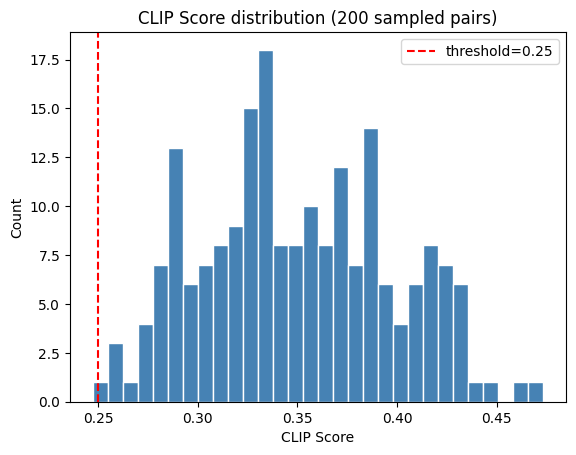

In [ ]:
from scripts.verify_dataset import compute_clip_scores
import matplotlib.pyplot as plt
import numpy as np

scores = compute_clip_scores(
    f'{DRIVE_ROOT}/data/captioned_pairs.jsonl',
    sample_size=200,
    seed=42,
)
print(f"CLIP Score — mean={np.mean(scores):.3f}, "
      f"min={np.min(scores):.3f}, max={np.max(scores):.3f}")
print(f"Pairs above 0.25: {sum(s >= 0.25 for s in scores)}/200")

plt.hist(scores, bins=30, color='steelblue', edgecolor='white')
plt.axvline(0.25, color='red', linestyle='--', label='threshold=0.25')
plt.xlabel("CLIP Score")
plt.ylabel("Count")
plt.title("CLIP Score distribution (200 sampled pairs)")
plt.legend()
plt.savefig(f'{DRIVE_ROOT}/results/metrics/clip_score_distribution.png', dpi=150)
plt.show()

In [ ]:
import json, random

random.seed(42)
with open(f'{DRIVE_ROOT}/data/captioned_pairs.jsonl') as f:
    all_pairs = [json.loads(l) for l in f]

random.shuffle(all_pairs)

# Open SVG-logo datasets are small (~800 pairs); a single train split is the honest choice.
# Reserve 500 for held-out test, use the rest for training.
TEST_SIZE = 500
if len(all_pairs) <= TEST_SIZE:
    raise RuntimeError(
        f"Only {len(all_pairs)} pairs available — need more than {TEST_SIZE} "
        f"to leave any data for training. Add more datasets in notebook 01."
    )

test  = all_pairs[:TEST_SIZE]
train = all_pairs[TEST_SIZE:]

print(f"Total: {len(all_pairs)} pairs → test={len(test)}, train={len(train)}")

def save_split(pairs, path, split_name):
    with open(path, 'w', encoding='utf-8') as f:
        for item in pairs:
            f.write(json.dumps({**item, 'split': split_name}) + '\n')
    print(f"Saved {len(pairs)} pairs → {path}")

save_split(test,  f'{DRIVE_ROOT}/data/test_500.jsonl', 'test')
save_split(train, f'{DRIVE_ROOT}/data/train.jsonl',    'train')

In [ ]:
import json

for name, path in [
    ('test_500', f'{DRIVE_ROOT}/data/test_500.jsonl'),
    ('train',    f'{DRIVE_ROOT}/data/train.jsonl'),
]:
    with open(path, encoding='utf-8') as f:
        items = [json.loads(l) for l in f]
    print(f"{name}: {len(items)} pairs")

with open(f'{DRIVE_ROOT}/data/test_500.jsonl', encoding='utf-8') as f:
    test_paths = {json.loads(l)['png_path'] for l in f}
with open(f'{DRIVE_ROOT}/data/train.jsonl', encoding='utf-8') as f:
    train_paths = {json.loads(l)['png_path'] for l in f}

assert len(test_paths & train_paths) == 0, "OVERLAP: test_500 and train share images!"
print(f"PASS: test_500 ({len(test_paths)}) and train ({len(train_paths)}) are disjoint")